## Intro to Python Programming
- Prof Joanna Bieri
- Office: Duke 209

### Today you should submit your Initial Project Proposal.

See our class website for more information about the proposal and how to check your grade in this class.

### Day 13 - Review - Putting it all together.

Today's practice problems are your opportunity to review the work we have done so far and really put it all togehter into a few interesting pieces of code.


In [1]:
# Here are the packages you will probably need
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from skimage.io import imshow, imread

### Load in some data

Here you will load in a .csv file that contains data about names given to babies in the United States for multiple different years. Your goal will be to do a bunch of things with this data - practicing all of the things we have learned so far in the class.

In [2]:
# Load the data
file_name = 'names_by_birth_year.csv'
website = 'https://joannabieri.com/python/'
DF = pd.read_csv(website+file_name)

#### Look at the top 20 entries in the DataFrame, just to get familiar with what the data looks like.

- Can you figure out what data type is in each column?

In [3]:
# Your code here

display(DF.head(20))

,Year,Name,Gender,Count
0,1883,Mary,F,8012
1,1883,Anna,F,3306
2,1883,Emma,F,2367
3,1883,Elizabeth,F,2255
4,1883,Minnie,F,2035
5,1883,Margaret,F,1881
6,1883,Bertha,F,1681
7,1883,Ida,F,1634
8,1883,Annie,F,1589
9,1883,Clara,F,1548


#### Get a list of the column names

In [4]:
# Your code here

for k in DF.keys():
    print(k)

Year
Name
Gender
Count


#### Write code that searches the DataFrame to see how many people were born in the USA with your name in the same year you were born.

In [14]:
# Your code here

# (DF['Year'] == 2004).sum()
DF[(DF['Name'] == name) & (DF['Year'] == year)]


,Year,Name,Gender,Count
343183,2004,Carmen,F,1363
364625,2004,Carmen,M,36


#### Make a list of names of your family and friends and another list with each of their birthdays. Check to see how many people were born with their names in their birth years. Make sure to check the case that their names were not found.

In [17]:
# Your code here

my_dict = {'Sydney':2003,
           'Averie':2006,
           'Carmen':2004
          }

for name, year in my_dict.items():
    result = DF[(DF['Name'] == name) & (DF['Year'] == year)]
    if len(result) > 0:
        count = result['Count'].values[0]
        print(f"{count} {name}'s in {year}.")
    else:
        print(f"{name} was not found in {year}.")

8911 Sydney's in 2003.
292 Averie's in 2006.
1363 Carmen's in 2004.


#### Write code that asks a user for their name and birthday date and then returns the information about their name

Make sure you input the year as an integer and ensure their name starts with a capital letter.

In [35]:
# Your code here

user_name = input('Your name:').capitalize()
user_birthday = int(input('Your birthday year:'))

result = DF[(DF['Name'] == user_name) & (DF['Year'] == user_birthday)]

if len(result) == 0:
    print("No data found")
else:
    print(result)

Your name: mazzie
Your birthday year: 2004


        Year    Name Gender  Count
353375  2004  Mazzie      F     10


#### Write code that finds out how many years the data set covers

- What is the minimum year
- What is the maximum year

NOTE - The dataframe is not orderd automatically by year.

In [28]:
# Your code here

year_set = set(DF['Year'])
year_count = len(year_set)
print(year_count)

143


In [29]:
(DF['Year']).min()

1880

In [33]:
(DF['Year']).max()

2022

#### Write code that finds out how many unique names there are in the data set

In [34]:
# Your code here

name_set = set(DF['Name'])
name_count = len(name_set)
print(name_count)

102449


#### Count up the total number of people recorded for each year. Print out the data in order of year. Assign that data to a variable (either a list or a dictionary)

In [40]:
# Your code here

year_totals = DF.groupby('Year')['Count'].sum().sort_index()
year_totals_dict = year_totals.to_dict()
year_totals_dict

{1880: 201484,
 1881: 192690,
 1882: 221533,
 1883: 216945,
 1884: 243461,
 1885: 240854,
 1886: 255317,
 1887: 247393,
 1888: 299473,
 1889: 288946,
 1890: 301401,
 1891: 286671,
 1892: 334374,
 1893: 325223,
 1894: 338690,
 1895: 351021,
 1896: 357484,
 1897: 346957,
 1898: 381456,
 1899: 339233,
 1900: 450261,
 1901: 345812,
 1902: 386732,
 1903: 381202,
 1904: 403485,
 1905: 423925,
 1906: 428451,
 1907: 465392,
 1908: 488652,
 1909: 511224,
 1910: 590712,
 1911: 644279,
 1912: 988060,
 1913: 1137111,
 1914: 1416346,
 1915: 1832430,
 1916: 1934418,
 1917: 2006755,
 1918: 2171110,
 1919: 2110251,
 1920: 2262650,
 1921: 2334504,
 1922: 2289152,
 1923: 2302494,
 1924: 2381621,
 1925: 2333321,
 1926: 2295896,
 1927: 2319355,
 1928: 2260901,
 1929: 2192169,
 1930: 2223280,
 1931: 2104348,
 1932: 2111263,
 1933: 1999408,
 1934: 2076766,
 1935: 2089819,
 1936: 2077525,
 1937: 2130624,
 1938: 2212563,
 1939: 2203405,
 1940: 2302599,
 1941: 2436340,
 1942: 2731726,
 1943: 2822506,
 1944: 26

#### Plot the number of people born for each year over time

The x-axis should be years ranging from 1880-2022

The y-axis should be from the data above where you counted the total number born

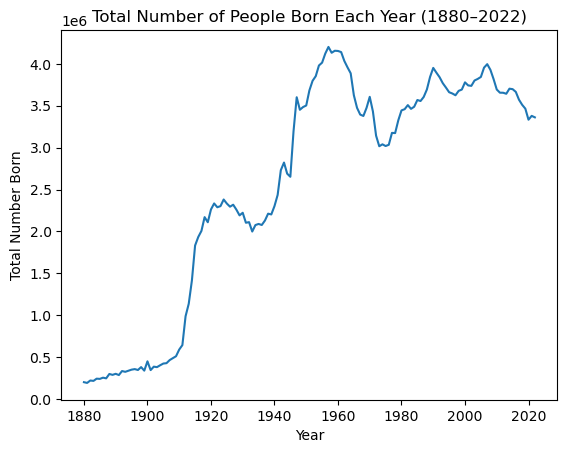

In [42]:
# Your code here

import matplotlib.pyplot as plt

plt.figure()
plt.plot(year_totals.index, year_totals.values)
plt.xlabel("Year")
plt.ylabel("Total Number Born")
plt.title("Total Number of People Born Each Year (1880–2022)")
plt.show()

#### Create a graph that tracks the popularity of your name over time from 1880 to 2022

The x-axis should be years ranging from 1880-2022

The y-axis should be the percent of names in each year matching your name.

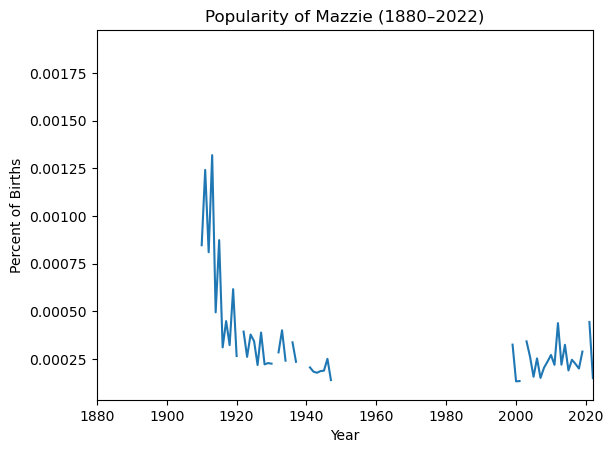

In [44]:
# Your code here

year_totals = DF.groupby('Year')['Count'].sum()
my_name = "Mazzie"

name_data = DF[DF['Name'] == my_name]
name_totals = name_data.groupby('Year')['Count'].sum()

percent_per_year = (name_totals / year_totals) * 100

import matplotlib.pyplot as plt
plt.figure()
plt.plot(percent_per_year.index, percent_per_year.values)
plt.xlim(1880, 2022)
plt.xlabel("Year")
plt.ylabel("Percent of Births")
plt.title("Popularity of Mazzie (1880–2022)")
plt.show()

### Create a name guessing game!

- Let people guess the most popular name for a given year
- First get the information for the most popular name each year one for males and one for females

- Choose a random year
- Get the most popular name that year chosing randomly from M or F
- Tell the person the length of the name and whether it is from the Male or Female list
- Let them guess or quit
- Each time they get a guess wrong give them a letter in the name (in order)
- Congratulate them when they get the name corrrect.

In [108]:
# Your code here



### Imagine you are a business consultant and are contacted by the owner of a gift shop. Your job is to send them data to help their inventory:

- Thier shop is near a popular college town where lots of people ages 18-24 live
- The students visit the shop and buy all sorts of stuff
- The shop owner wants to expand their inventory to include named items
- Think those silly named keychains only better!

- You have been tasked to suggest which names should be printed on the merchendise 
- The goal is to sell the most of the product
- You can also add names that you just like :)

#### Write code that takes as an input a range of birth years and the number of names required. Cycle through each birth year adding both male and female names to the list of names. Stop once you have reach the number of names the shop owner requires

#### Wite this list of names to the file merch_names.txt

In [45]:
# Your code here

start_year = int(input('Type in a starting year after 1880:'))
end_year = int(input('Type in an ending year less than 2022:'))
num_names = int(input('Type in the number of names you want: '))

year = start_year
count = 0
names = []

while True:
    
    DF_year = DF[DF['Year']==year]

    g_mask = DF_year['Gender']=='F'
    f_name = DF_year[g_mask].sort_values('Count',ascending=False).iloc[count]['Name']
    if f_name not in names and len(names)<num_names:
        names.append(f_name)

    g_mask = DF_year['Gender']=='M'
    m_name = DF_year[g_mask].sort_values('Count',ascending=False).iloc[count]['Name']
    if m_name not in names and len(names)<num_names:
        names.append(m_name)
    
    if len(names) == num_names:
        break
    
    count +=1
    year +=1
    if year > end_year:
        year = start_year
        
print('Saving the list of names to merch_names.txt.')

with open('merch_names.txt', mode = 'w') as save_names:
    for name in names:
        save_names.write(name+'\n')

Type in a starting year after 1880: 1900
Type in an ending year less than 2022: 1980
Type in the number of names you want:  10


Saving the list of names to merch_names.txt.
